# Phase 4: Model Implementation - Bidirectional LSTM (Bi-LSTM) [v5]

Pada notebook ini kita akan membangun, melatih, dan mengevaluasi model **Bidirectional LSTM**.
LSTM sangat baik dalam menangkap long-range dependencies pada sekuens asam amino, memahami "grammar" urutan protein dalam menentukan fungsi.

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json

# Set device ke CUDA jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan device: {device}")

os.makedirs('models', exist_ok=True)
os.makedirs('data/results', exist_ok=True)

Menggunakan device: cuda


In [13]:
# 1. Load Dataset
train_df = pd.read_csv('data/processed/train.csv')
test_df = pd.read_csv('data/processed/test.csv')

with open('data/processed/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

num_classes = len(label_mapping)
print(f"Data Train: {len(train_df)}, Data Test: {len(test_df)}, Jumlah Kelas: {num_classes}")

Data Train: 20073, Data Test: 5019, Jumlah Kelas: 6


In [14]:
MAX_LEN = 1000
BATCH_SIZE = 64  # VRAM 4GB (attention removed)

train_dataset = ProteinDataset(train_df['Sequence'], train_df['Label'], max_len=MAX_LEN)
test_dataset = ProteinDataset(test_df['Sequence'], test_df['Label'], max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("DataLoader siap.")

DataLoader siap.


In [15]:
# 3. Definisi Focal Loss + Label Smoothing dan Arsitektur LSTM
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        if self.label_smoothing > 0:
            n_classes = inputs.size(-1)
            with torch.no_grad():
                smoothed = torch.full_like(inputs, self.label_smoothing / (n_classes - 1))
                smoothed.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
            log_probs = F.log_softmax(inputs, dim=-1)
            ce_loss = -(smoothed * log_probs).sum(dim=-1)
            if self.alpha is not None:
                ce_loss = ce_loss * self.alpha.gather(0, targets)
        else:
            ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class ProteinLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super(ProteinLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(p=0.2)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            bidirectional=True, batch_first=True,
                            dropout=0.4 if num_layers > 1 else 0)

        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        fc_input_dim = hidden_dim * 2 * 2
        self.fc = nn.Sequential(
            nn.Linear(fc_input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        for module in self.fc:
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = self.embedding(x)
        x = self.embedding_dropout(x)
        lstm_out, _ = self.lstm(x)

        lstm_out = lstm_out.transpose(1, 2)
        max_pooled = self.global_max_pool(lstm_out).squeeze(-1)
        avg_pooled = self.global_avg_pool(lstm_out).squeeze(-1)
        pooled = torch.cat([max_pooled, avg_pooled], dim=1)
        return self.fc(pooled)

EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
model = ProteinLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, num_classes).to(device)
print(model)

ProteinLSTM(
  (embedding): Embedding(21, 128, padding_idx=0)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [16]:
# 4. Konfigurasi Pelatihan

# Menghitung Class Weights
labels_array = train_df['Label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = FocalLoss(alpha=class_weights_tensor, gamma=1.0, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-5)

# ReduceLROnPlateau Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 50
PATIENCE = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
best_epoch = 0
epochs_no_improve = 0
early_stop_triggered = False
best_model_path = 'models/lstm_model_best.pth'

print("\nMemulai proses pelatihan...")
for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- FASE TRAINING ---
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * seqs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = train_loss / total
    epoch_train_acc = correct / total
    
    # --- FASE TESTING ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * seqs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    # Step scheduler
    scheduler.step(epoch_val_loss)
    
    # Menyimpan history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    elapsed_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Waktu: {elapsed_time:.0f}s | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Test Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\n[Early Stopping Triggered] No improvement for {PATIENCE} consecutive epochs.")
            early_stop_triggered = True
            break

print("\n--- Training Summary ---")
print(f"Early Stopping Triggered: {early_stop_triggered}")
print(f"Total Epochs Run: {epoch + 1}")
print(f"Best Epoch: {best_epoch} (Test Loss: {best_val_loss:.4f})")
model.load_state_dict(torch.load(best_model_path, weights_only=False))
print("Best model weights loaded.")


Memulai proses pelatihan...
Epoch 01/50 | Waktu: 284s | LR: 0.000500 | Train Loss: 1.0942 Acc: 0.4519 | Test Loss: 0.8075 Acc: 0.6414
Epoch 02/50 | Waktu: 283s | LR: 0.000500 | Train Loss: 0.8177 Acc: 0.6403 | Test Loss: 0.6880 Acc: 0.7300
Epoch 03/50 | Waktu: 287s | LR: 0.000500 | Train Loss: 0.7163 Acc: 0.7094 | Test Loss: 0.6341 Acc: 0.7521
Epoch 04/50 | Waktu: 282s | LR: 0.000500 | Train Loss: 0.6620 Acc: 0.7400 | Test Loss: 0.5811 Acc: 0.7806
Epoch 05/50 | Waktu: 289s | LR: 0.000500 | Train Loss: 0.6325 Acc: 0.7582 | Test Loss: 0.5912 Acc: 0.7828
Epoch 06/50 | Waktu: 283s | LR: 0.000500 | Train Loss: 0.5966 Acc: 0.7844 | Test Loss: 0.5288 Acc: 0.8145
Epoch 07/50 | Waktu: 283s | LR: 0.000500 | Train Loss: 0.5744 Acc: 0.7974 | Test Loss: 0.5337 Acc: 0.8049
Epoch 08/50 | Waktu: 283s | LR: 0.000500 | Train Loss: 0.5432 Acc: 0.8152 | Test Loss: 0.5015 Acc: 0.8267
Epoch 09/50 | Waktu: 284s | LR: 0.000500 | Train Loss: 0.5178 Acc: 0.8314 | Test Loss: 0.4918 Acc: 0.8294
Epoch 10/50 | Wak


--- Classification Report ---
                      precision    recall  f1-score   support

                GPCR       0.96      0.98      0.97       664
           Hydrolase       0.77      0.83      0.80       857
         Ion Channel       0.96      0.96      0.96       894
              Kinase       0.90      0.89      0.90       837
      Oxidoreductase       0.88      0.85      0.86       906
Transcription Factor       0.90      0.87      0.88       861

            accuracy                           0.89      5019
           macro avg       0.90      0.90      0.90      5019
        weighted avg       0.89      0.89      0.89      5019


MCC Score: 0.8710


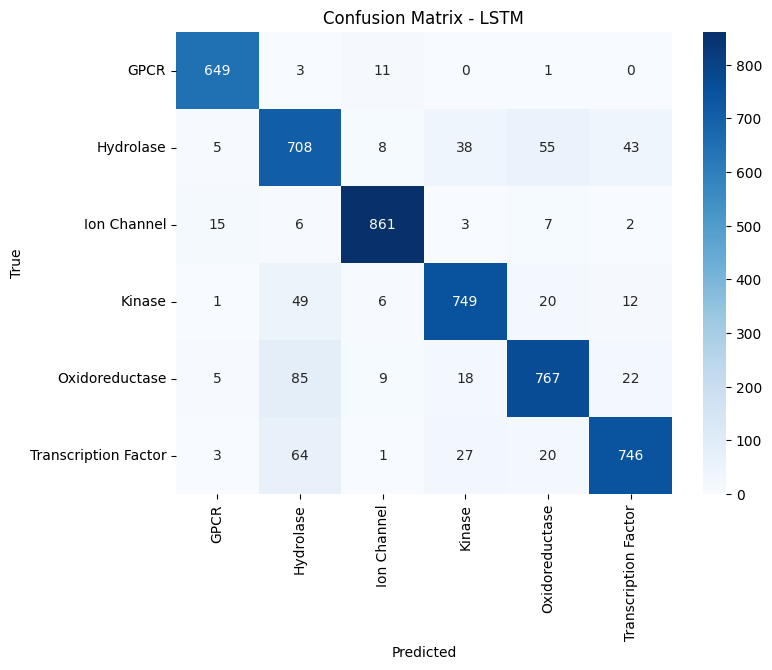

Model LSTM dan hasil evaluasi berhasil disimpan.


In [19]:
# 5. Evaluasi Metrik dan Simpan Model
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Classification Report ---")
class_names = [label_mapping[str(i)] for i in range(num_classes)]
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

mcc = matthews_corrcoef(all_labels, all_preds)
print(f"\nMCC Score: {mcc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - LSTM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Simpan metrik performa
results = {
    'accuracy': accuracy_score(all_labels, all_preds),
    'f1_macro': f1_score(all_labels, all_preds, average='macro'),
    'mcc': mcc,
    'history': history
}
with open('data/results/lstm_metrics.json', 'w') as f:
    json.dump(results, f)

# Simpan bobot (weights) model
torch.save(model.state_dict(), 'models/lstm_model.pth')
print("Model LSTM dan hasil evaluasi berhasil disimpan.")

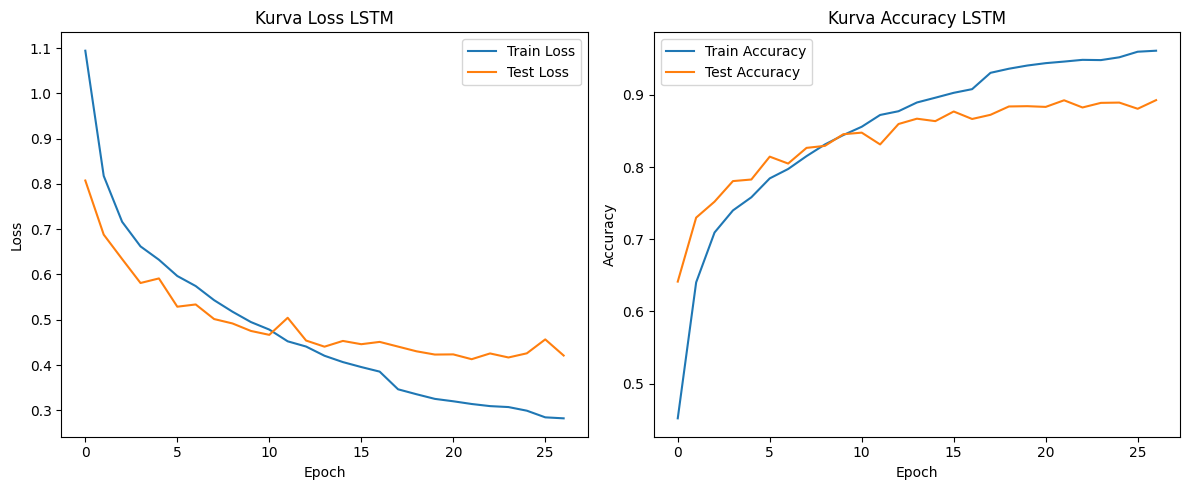

In [20]:
# 6. Visualisasi Kurva Loss & Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Test Loss')
plt.title('Kurva Loss LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Test Accuracy')
plt.title('Kurva Accuracy LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()